> **Purpose:** Real 600-tree FASTA/Newick benchmark: operator comparison (Fiedler-on-S vs Griffing-on-D vs L_sym), STDR validity gate, η histograms, recovery curves.  
> **Data:** real

# Real-data sub-sampling recovery (the naive algorithm)

The thesis's naive method: sub-sample the **Laplacian of the real-data similarity matrix** and see
how well the spectral partition survives.

**Protocol**
1. $S = \text{JC\_similarity(sequences)}$; reference partition $=$ STDR split
   (`partition_taxa` on the Fiedler vector of $L(S)=\operatorname{Deg}-S$).
   Keep a tree only if its reference partition is a **valid single edge** of the true tree.
2. On the valid trees, run the **standard bootstrap $p$-sweep**: sub-sample $S\to\hat S$, recompute
   the partition, and report **partition agreement, ARI, NMI** vs $p$.

Reuses the exact synthetic-experiment code: `bootstrap_p_sweep_simple` (`src/runners/p_sweep_inner.py`),
`compute_reference_partition_and_quality`, `check_partition_valid_in_tree`.

In [1]:
%load_ext autoreload
%autoreload 2

import os, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_R = Path.cwd()
while _R.parent != _R and not (_R / "setup.py").exists():
    _R = _R.parent
_root = str(_R / "sub_sampled_fielder_vec")   # sub_sampled_fielder_vec
_repo = str(_R)                               # spectral-tree-inference
for p in (_root, _repo):
    if p not in sys.path:
        sys.path.insert(0, p)
for _mod in [m for m in list(sys.modules) if m.startswith(('scripts.', 'src.'))]:
    del sys.modules[_mod]

import dendropy
import spectraltree
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform
from matplotlib.colors import ListedColormap
from src.core.utils import compute_laplacian, compute_fiedler_from_laplacian, compute_normalized_laplacian
from src.utils.metrics import compute_reference_partition_and_quality
from src.utils.partition_validity import check_partition_valid_in_tree
from src.runners.p_sweep_inner import bootstrap_p_sweep_simple, _kmeans_bipartition
from src.utils.screening import run_screen
from spectraltree.spectral_tree_reconstruction import partition_taxa
from src.runners.real_data_bpart import fasta_to_distance
from src.utils.griffing import griffing_leading_eigvec, griffing_centered
from src.utils.bpart_sweep_cache import bpart_sweep_raw
from src.utils.operator_comparison import (
    tree_leaf_index, patristic_distance_matrix, p_star_per_tree,
    run_threshold_sweep, print_validity_table)
from src.plots.plot_operator_threshold import (
    plot_eta_histograms, plot_operator_threshold_bars)

COLOR_POS, COLOR_NEG = '#d97706', '#1d4ed8'   # orange / blue (sign partition)

# fasta: full 600-tree download (extracted); newick: 600 trees already on disk
FASTA_DIR  = Path('/Users/itayg/PythonRepo/spectral-tree-inference/data/Datasets/Fasta 1000 taxa/extracted/fasta')
NEWICK_DIR = Path(_root) / 'data' / 'real_datasets' / 'Datasets' / '1000 taxa' / 'newick'

# --- experiment parameters ---
RUN_SWEEP      = False   # screen-only pass: count valids + eta histogram. Flip True for the p-sweep.
P_VALUES       = list(np.logspace(-2, 0, 20))   # 0.01 .. 1.0, 20 log-spaced points
BOOTSTRAP_REPS = 10
NUM_GAPS       = 10
MIN_SPLIT      = 5        # STDR/test practice; min_split=1 gives a degenerate 1/999 split at n=1000
M_TAXA         = 1000
ETA_THR        = (M_TAXA / np.log(M_TAXA)) ** (1/3)   # recoverability threshold (Cor. imbalance) ~5.25
SCREEN_IDS     = [f'random_tree_{i:03d}' for i in range(1, 601)]

def load_S(tree_id):
    cm = dendropy.DnaCharacterMatrix.get(path=str(FASTA_DIR / f'{tree_id}.fasta'), schema='fasta')
    obs, meta = spectraltree.charmatrix2array(cm)
    labels = [str(t.label) for t in list(meta)]
    S = spectraltree.JC_similarity_matrix(obs)
    tree = dendropy.Tree.get(path=str(NEWICK_DIR / f'{tree_id}.nwk'), schema='newick',
                             preserve_underscores=True, taxon_namespace=cm.taxon_namespace)
    tree.encode_bipartitions()
    return S, labels, tree

print(f'setup ok — {len(SCREEN_IDS)} ids to screen; eta threshold ~{ETA_THR:.2f}')
print('fasta:', FASTA_DIR)

def _load_all(tid):
    fpath = FASTA_DIR / f'{tid}.fasta'
    if not fpath.exists():
        return None
    S, labels, tree = load_S(tid)
    D, names = fasta_to_distance(str(fpath))
    nidx = {n: i for i, n in enumerate(names)}
    perm = np.array([nidx[l] for l in labels])
    D = D[perm][:, perm]            # align D to labels order
    return S, labels, tree, D

# Notebook data caches live in one place, not beside the notebook:
# analysis/notebooks_cache/distance_vs_similarity_real/. They are tracked so re-plotting works
# in a fresh clone without re-running the expensive 600-tree screens.
CACHE_DIR = Path(_root) / "analysis" / "notebooks_cache" / "distance_vs_similarity_real"
CACHE_DIR.mkdir(parents=True, exist_ok=True)


setup ok — 600 ids to screen; eta threshold ~5.25
fasta: /Users/itayg/PythonRepo/spectral-tree-inference/data/Datasets/Fasta 1000 taxa/extracted/fasta


## Step 1 — STDR partition of full $S$ + validity gate

Keep only trees whose full-$S$ STDR partition is a single real edge of the true tree.

In [2]:
# Screen 1 — Fiedler-on-S (unnormalized Laplacian L=Deg(S)-S, sigma2 threshold).
valid_ids, etas_valid, rows = run_screen(
    SCREEN_IDS, _load_all,
    lambda S, D: compute_reference_partition_and_quality(
        compute_fiedler_from_laplacian(compute_laplacian(S)), S,
        num_gaps=NUM_GAPS, min_split=MIN_SPLIT)[0],
    CACHE_DIR / 'screen_cache_600.npz', label='Fiedler-on-S')
fiedler_valid_ids = list(valid_ids)
n_valid = len(valid_ids)
print(f'{n_valid}/{len(rows)} trees: full-S Fiedler partition is a valid single tree edge '
      f'(num_gaps={NUM_GAPS}, min_split={MIN_SPLIT})')
pd.DataFrame(rows).set_index('tree')


loaded Fiedler-on-S from cache (screen_cache_600.npz)
327/600 trees: full-S Fiedler partition is a valid single tree edge (num_gaps=10, min_split=5)


,eta,valid
tree,,
random_tree_001,199.000000,True
random_tree_002,141.857143,False
random_tree_003,199.000000,True
random_tree_004,124.000000,False
random_tree_005,165.666667,False
...,...,...
random_tree_596,199.000000,True
random_tree_597,199.000000,True
random_tree_598,199.000000,False


## Comparison mode — Fiedler-on-$S$ vs Griffing-on-$D$ vs Fiedler-on-$L_{\rm sym}$

Same validity gate, three reference operators (similarity, distance, normalised Laplacian). The Griffing screen is cached separately
(`screen_griffing_600.npz`); the cell below loads it (or recomputes if absent).

In [3]:
# Screen 2 — Griffing-on-D (leading eigvec of B=HDH, sign threshold tau=0).
griff_valid_ids, griff_etas, griff_rows = run_screen(
    SCREEN_IDS, _load_all,
    lambda S, D: (griffing_leading_eigvec(D) >= 0),
    CACHE_DIR / 'screen_griffing_600.npz', label='Griffing-on-D')
print(f'griffing-on-D: {len(griff_valid_ids)} valid   '
      f'eta min/median/max = {griff_etas.min():.1f}/{np.median(griff_etas):.1f}/{griff_etas.max():.1f}')


loaded Griffing-on-D from cache (screen_griffing_600.npz)
griffing-on-D: 215 valid   eta min/median/max = 1.0/1.5/4.2


In [4]:
# Screen 3 — Fiedler-on-L_sym (normalized Laplacian I-D^-1/2 S D^-1/2, sigma2 threshold).
lsym_valid_ids, lsym_etas, lsym_rows = run_screen(
    SCREEN_IDS, _load_all,
    lambda S, D: compute_reference_partition_and_quality(
        compute_fiedler_from_laplacian(compute_normalized_laplacian(S)), S,
        num_gaps=NUM_GAPS, min_split=MIN_SPLIT)[0],
    CACHE_DIR / 'screen_lsym_600.npz', label='L_sym')
print(f'L_sym: {len(lsym_valid_ids)}/{len(SCREEN_IDS)} valid   '
      f'eta min/median/max = {lsym_etas.min():.1f}/{np.median(lsym_etas):.1f}/{lsym_etas.max():.1f}')


loaded L_sym from cache (screen_lsym_600.npz)
L_sym: 68/600 valid   eta min/median/max = 1.0/3.8/51.6


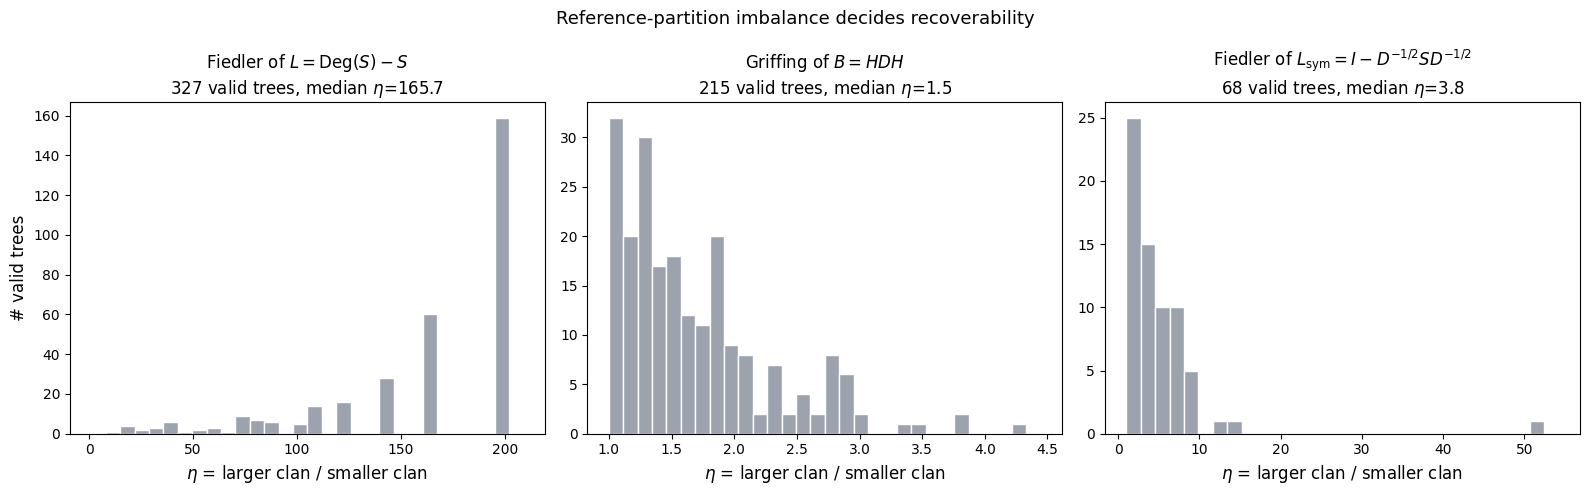

In [5]:
# side-by-side eta histograms for all three methods — each on its OWN x-range
# (a shared scale hides the Griffing / L_sym shapes). Titles give the matrix whose spectrum is used.
plot_eta_histograms([
    (etas_valid, r'Fiedler of $L=\mathrm{Deg}(S)-S$'),
    (griff_etas, r'Griffing of $B=HDH$'),
    (lsym_etas,  r'Fiedler of $L_{\rm sym}=I-D^{-1/2}SD^{-1/2}$'),
])


### Partition imbalance by operator × threshold rule (real 600-tree benchmark)

How the threshold rule (σ₂-gap, k-means, sign τ=0) reshapes the imbalance η of the partition each operator (L, L_sym, B) picks — valid-only (the partition is a real clan).

In [6]:
# Threshold-rule sweep: the real 600-tree benchmark x {L, L_sym, B} x {sigma2, k-means, sign}.
# Valid-only: keep a tree's partition imbalance eta only when that partition is a real
# single-edge clan of the true tree. Cached (lightweight: just the eta arrays + counts).
OPERATORS = {
    'L':     lambda S, D: compute_fiedler_from_laplacian(compute_laplacian(S)),
    'L_sym': lambda S, D: compute_fiedler_from_laplacian(compute_normalized_laplacian(S)),
    'B':     lambda S, D: griffing_leading_eigvec(D),
}
THRESHOLDS = {
    '$\\sigma_2$': lambda v, S: partition_taxa(v, S, NUM_GAPS, MIN_SPLIT),
    'k-means':     lambda v, S: _kmeans_bipartition(v, MIN_SPLIT),
    'sign':        lambda v, S: (v >= 0),
}
_op_names, _thr_names = list(OPERATORS), list(THRESHOLDS)

thr_etas, THR_N = run_threshold_sweep(
    SCREEN_IDS, _load_all, OPERATORS, THRESHOLDS,
    CACHE_DIR / 'threshold_eta_600.npz',
    dict(ids=len(SCREEN_IDS), min_split=MIN_SPLIT, num_gaps=NUM_GAPS))
print_validity_table(thr_etas, _op_names, _thr_names, THR_N)


loaded threshold-eta cache (threshold_eta_600.npz)

valid partitions / 600 screened:
      op | $\sigma_2$ |  k-means |     sign
       L |      327 |      590 |      310
   L_sym |       68 |      446 |      219
       B |       91 |      443 |      215


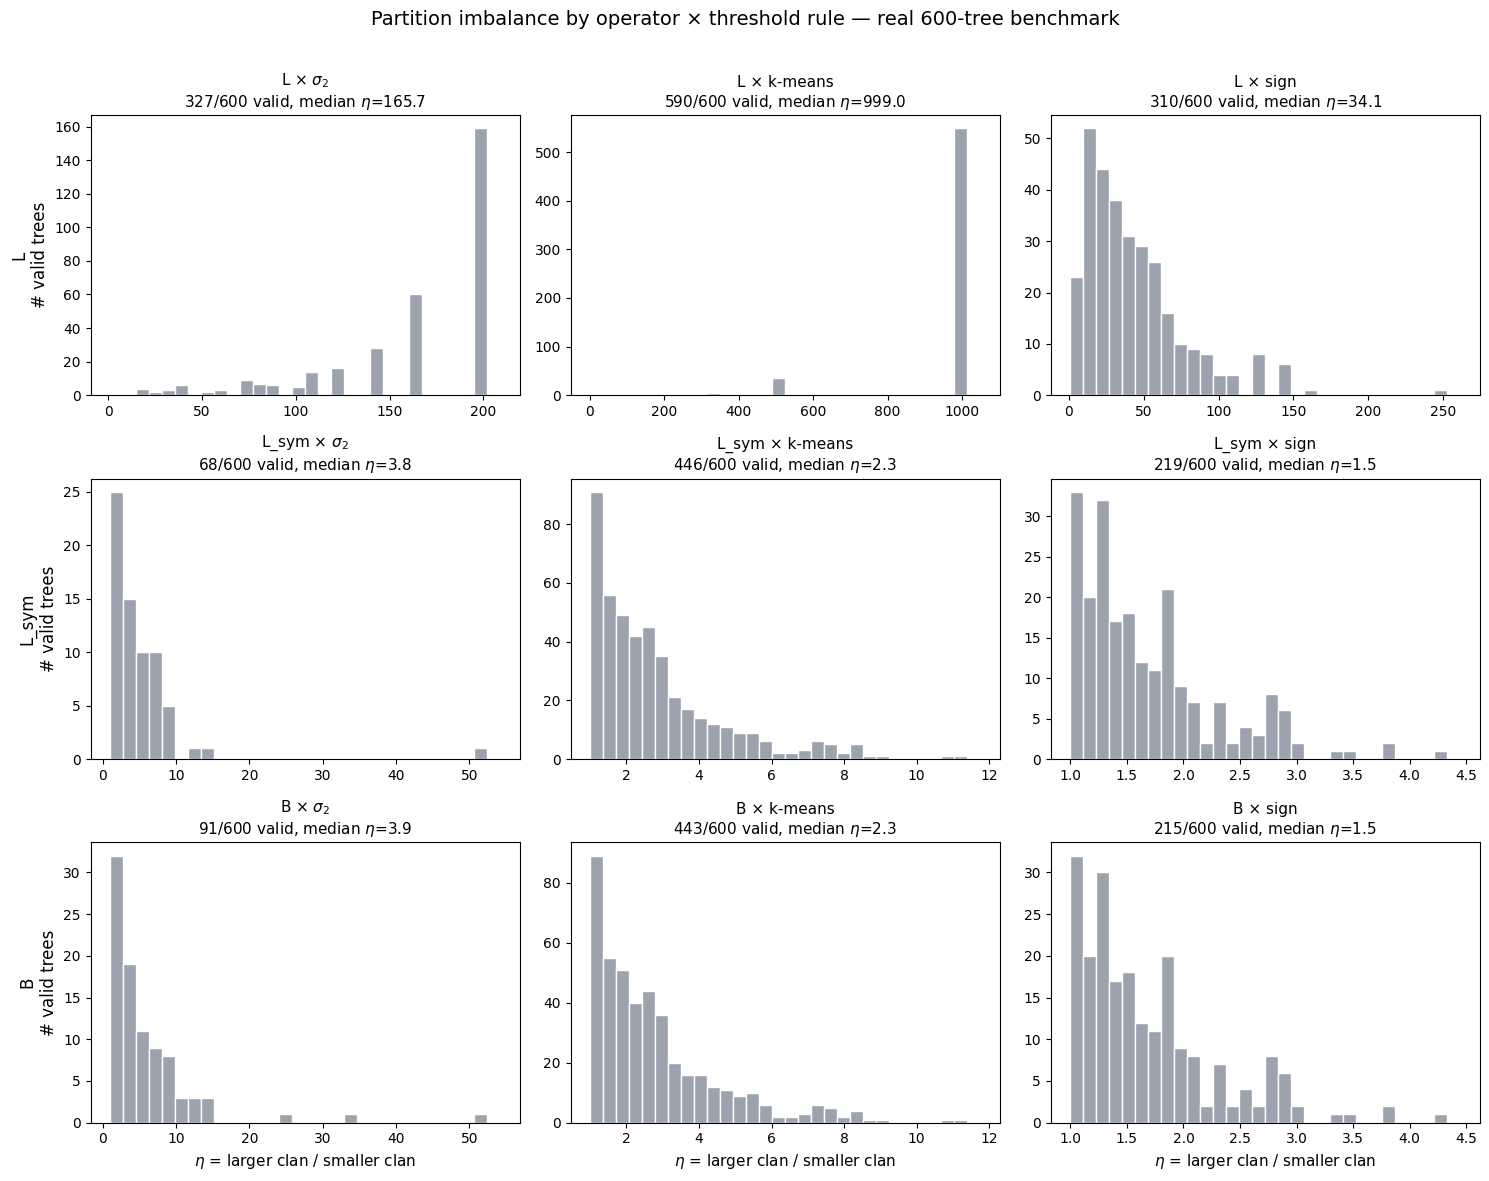

In [7]:
# 3x3 histogram grid: rows = operator (L, L_sym, B), cols = threshold (sigma2, k-means, sign).
# Valid-only partition imbalance eta; each panel on its OWN x-range.
fig, axes = plt.subplots(len(_op_names), len(_thr_names), figsize=(15, 12))
for r, op in enumerate(_op_names):
    for c, thr in enumerate(_thr_names):
        ax = axes[r, c]
        data = np.asarray(thr_etas[(op, thr)], float)
        if data.size:
            ax.hist(data, bins=30, range=(1, max(data.max() * 1.05, 2.0)),
                    color='#9ca3af', edgecolor='white')
            med = np.median(data)
        else:
            med = float('nan')
        ax.set_title(f'{op} × {thr}\n{data.size}/{THR_N} valid, median $\\eta$={med:.1f}', fontsize=11)
        if r == len(_op_names) - 1:
            ax.set_xlabel(r'$\eta$ = larger clan / smaller clan', fontsize=11)
        if c == 0:
            ax.set_ylabel(f'{op}\n# valid trees', fontsize=12)
fig.suptitle('Partition imbalance by operator × threshold rule — real 600-tree benchmark', fontsize=14)
fig.tight_layout(rect=(0, 0, 1, 0.97)); plt.show()


#### Ranked bars (high → low): median $\eta$ with 95% CI, and # valid partitions

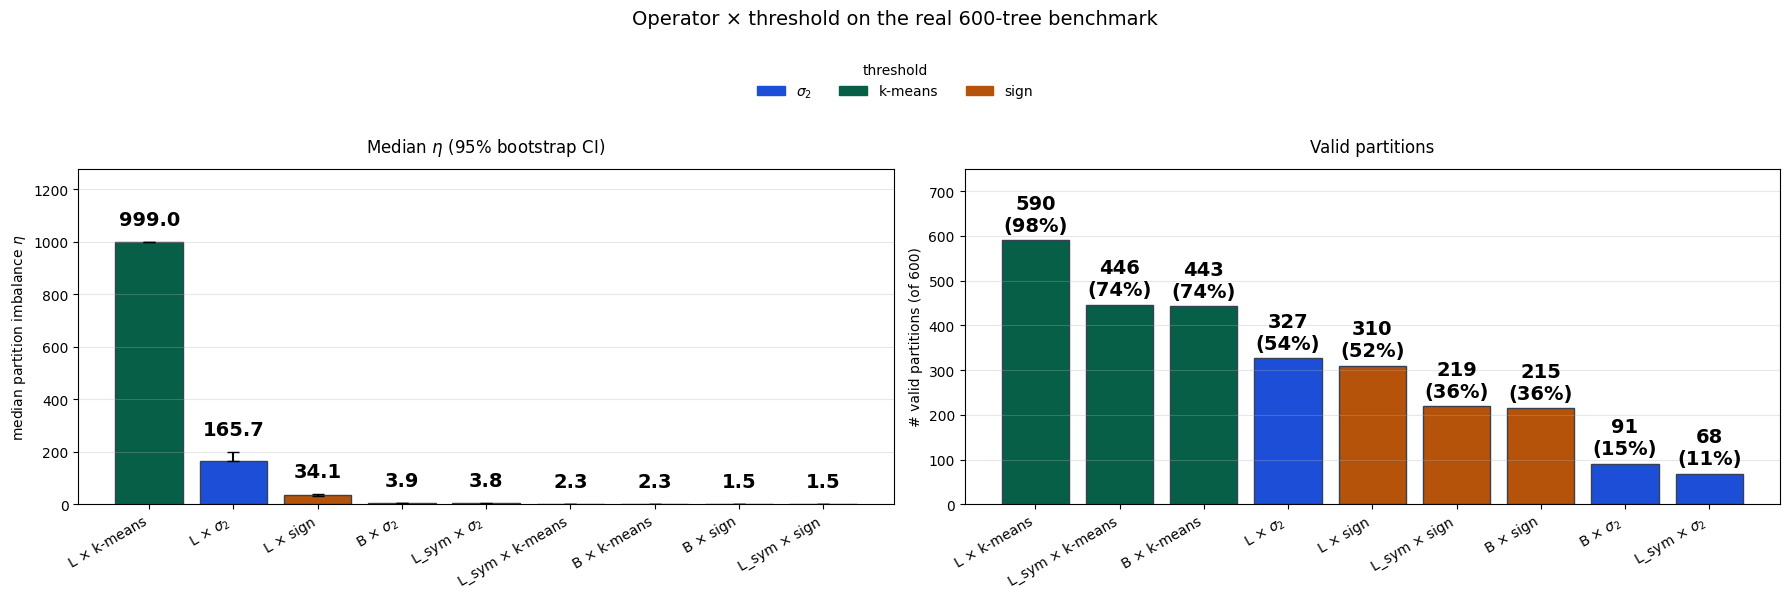

In [8]:
# Two barplots side by side: (left) median eta with 95% bootstrap CI; (right) # valid partitions.
# Both over the real 600-tree benchmark, sorted high -> low independently, colored by threshold rule.
plot_operator_threshold_bars(
    thr_etas, _op_names, _thr_names, THR_N,
    'Operator × threshold on the real 600-tree benchmark')


### Which trees does each method pick a valid partition on? *(no sub-sampling)*

Before discussing how robust each method is **under sub-sampling**, the prior question is
*partition choice on the full data*. The cells below cross-tabulate the three methods
(Fiedler-on-$S$, Griffing-on-$D$, Fiedler-on-$L_{\rm sym}$) over the screened trees:

- **P1** — validity **agreement matrix** across all three methods (which trees each validates, where they overlap).
- **P2** — joint scatter of $\eta_S$ vs $\eta_D$, one point per tree, colored by validity status.
- **P3** — the same 2×2, broken down by $\eta_S$ bucket — does $D$ rescue the high-$\eta_S$ trees where $S$ snips a degenerate fringe?
- **P4** — on the both-valid cohort, do the two methods pick the *same* partition (ARI / NMI), or different ones?

`both_valid_ids` (set by P1) is exported for use by the downstream recovery cell.

pairwise both-valid overlap (diagonal = total valid per method):
               Fiedler-$S$  Griffing-$D$  $L_{\rm sym}$
Fiedler-$S$            327           114             31
Griffing-$D$           114           215             33
$L_{\rm sym}$           31            33             68

valid in all THREE methods: 16
valid in at least one:      448 / 600


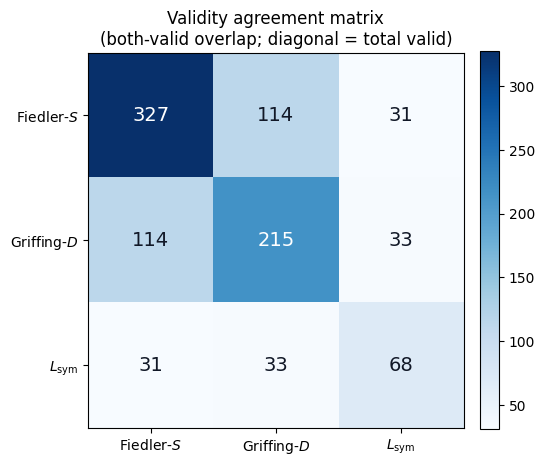


cohort used by every downstream P*/recovery panel: 114 trees valid in both Fiedler-$S$ and Griffing-$D$
  only-S: 213   only-D: 101   neither: 172


In [9]:
# P1 — validity agreement across ALL THREE methods over the full screen.
# Pure set arithmetic on the screen results: which trees does each method validate, and where do they overlap?
S_set = set(fiedler_valid_ids); D_set = set(griff_valid_ids); L_set = set(lsym_valid_ids)
N_TOTAL = len(SCREEN_IDS)

# downstream cohorts (S vs D) — consumed by the P2 / P4 / demo / recovery cells below
both_valid_ids = sorted(S_set & D_set)
only_S_ids     = sorted(S_set - D_set)
only_D_ids     = sorted(D_set - S_set)
neither_count  = N_TOTAL - len(S_set | D_set)

# 3x3 agreement matrix: diagonal = #valid for that method; (i, j) = #trees valid in BOTH i and j
methods = [('Fiedler-$S$', S_set), ('Griffing-$D$', D_set), ('$L_{\\rm sym}$', L_set)]
names = [m for m, _ in methods]
M = np.array([[len(si & sj) for _, sj in methods] for _, si in methods])
print('pairwise both-valid overlap (diagonal = total valid per method):')
print(pd.DataFrame(M, index=names, columns=names))
print(f'\nvalid in all THREE methods: {len(S_set & D_set & L_set)}')
print(f'valid in at least one:      {len(S_set | D_set | L_set)} / {N_TOTAL}')

# annotated heatmap of the agreement matrix
fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(M, cmap='Blues')
ax.set_xticks(range(3)); ax.set_xticklabels(names)
ax.set_yticks(range(3)); ax.set_yticklabels(names)
_thr = M.max() * 0.5 if M.max() else 1
for i in range(3):
    for j in range(3):
        ax.text(j, i, str(M[i, j]), ha='center', va='center', fontsize=14,
                color='white' if M[i, j] > _thr else '#111827')
ax.set_title('Validity agreement matrix\n(both-valid overlap; diagonal = total valid)', fontsize=12)
fig.colorbar(im, fraction=0.046, pad=0.04); fig.tight_layout(); plt.show()

print(f'\ncohort used by every downstream P*/recovery panel: '
      f'{len(both_valid_ids)} trees valid in both Fiedler-$S$ and Griffing-$D$')
print(f'  only-S: {len(only_S_ids)}   only-D: {len(only_D_ids)}   neither: {neither_count}')


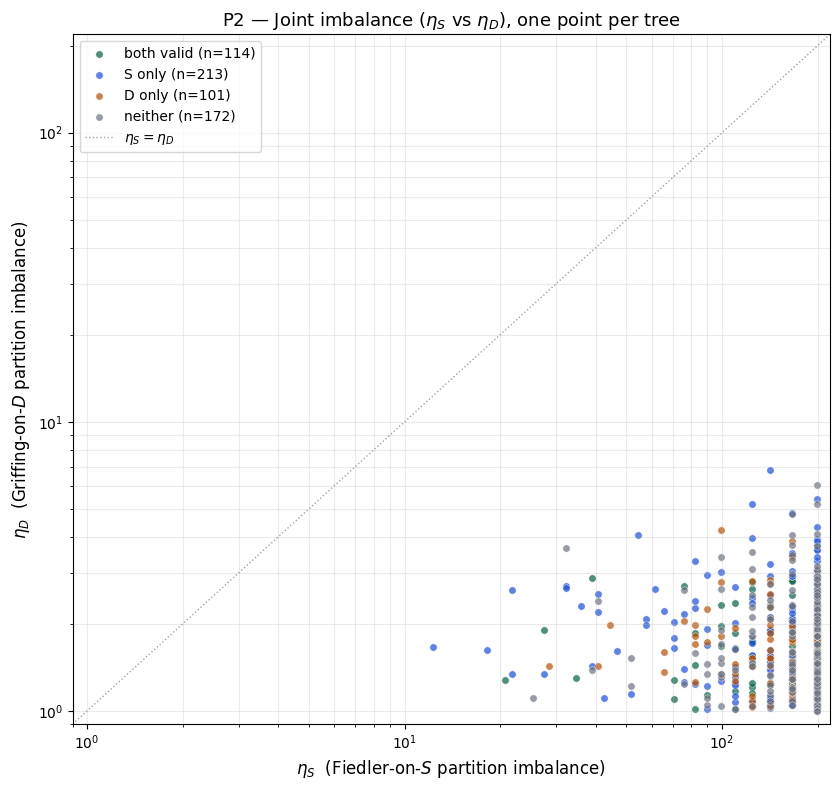

In [10]:
# P2 — joint eta scatter (eta_S vs eta_D), one point per tree.
# Build a per-tree dataframe from the cached screens so every screened tree has both etas
# (the screen stores eta even for invalid trees, so we don't need to re-screen anything).
eta_S_map   = {r['tree']: float(r['eta']) for r in rows}
valid_S_map = {r['tree']: bool(r['valid']) for r in rows}
eta_D_map   = {r['tree']: float(r['eta']) for r in griff_rows}
valid_D_map = {r['tree']: bool(r['valid']) for r in griff_rows}
all_tids = sorted(set(eta_S_map) | set(eta_D_map))
cmp_df = pd.DataFrame({
    'tree':    all_tids,
    'eta_S':   [eta_S_map.get(t, np.nan)   for t in all_tids],
    'eta_D':   [eta_D_map.get(t, np.nan)   for t in all_tids],
    'S_valid': [valid_S_map.get(t, False)  for t in all_tids],
    'D_valid': [valid_D_map.get(t, False)  for t in all_tids],
})
# Only trees where BOTH screens produced an eta can be plotted
plot_df = cmp_df.dropna(subset=['eta_S', 'eta_D']).copy()
both_msk  = plot_df['S_valid'] &  plot_df['D_valid']
only_S    = plot_df['S_valid'] & ~plot_df['D_valid']
only_D    = ~plot_df['S_valid'] &  plot_df['D_valid']
neither   = ~plot_df['S_valid'] & ~plot_df['D_valid']

fig, ax = plt.subplots(figsize=(8.5, 8))
for msk, col, lbl in [(both_msk, '#065f46', f'both valid (n={int(both_msk.sum())})'),
                      (only_S,   '#1d4ed8', f'S only (n={int(only_S.sum())})'),
                      (only_D,   '#b45309', f'D only (n={int(only_D.sum())})'),
                      (neither,  '#6b7280', f'neither (n={int(neither.sum())})')]:
    ax.scatter(plot_df.loc[msk, 'eta_S'], plot_df.loc[msk, 'eta_D'],
               color=col, alpha=0.7, s=28, label=lbl, edgecolor='white', linewidth=0.4)
ax.set_xscale('log'); ax.set_yscale('log')
lo = max(0.9, float(plot_df[['eta_S', 'eta_D']].min().min()) * 0.9)
hi = float(plot_df[['eta_S', 'eta_D']].max().max()) * 1.1
ax.plot([lo, hi], [lo, hi], color='#9ca3af', lw=1, ls=':', label='$\\eta_S = \\eta_D$')
ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
ax.set_xlabel(r'$\eta_S$  (Fiedler-on-$S$ partition imbalance)', fontsize=12)
ax.set_ylabel(r'$\eta_D$  (Griffing-on-$D$ partition imbalance)', fontsize=12)
ax.set_title('P2 — Joint imbalance ($\\eta_S$ vs $\\eta_D$), one point per tree', fontsize=13)
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, which='both', alpha=0.25)
fig.tight_layout(); plt.show()


### One tree, three partitions

Patristic tree + a solid 2-color sign strip per operator (one demo tree valid in **both** methods,
nearest the Griffing median $\eta$). Fiedler-on-$S$ snips a tiny fringe; Griffing-on-$D$ cuts the deep
balanced divide; Fiedler-of-$L(D)$ shown for contrast.

demo tree random_tree_557  (valid in both; griffing eta=1.49);  114 trees valid in both


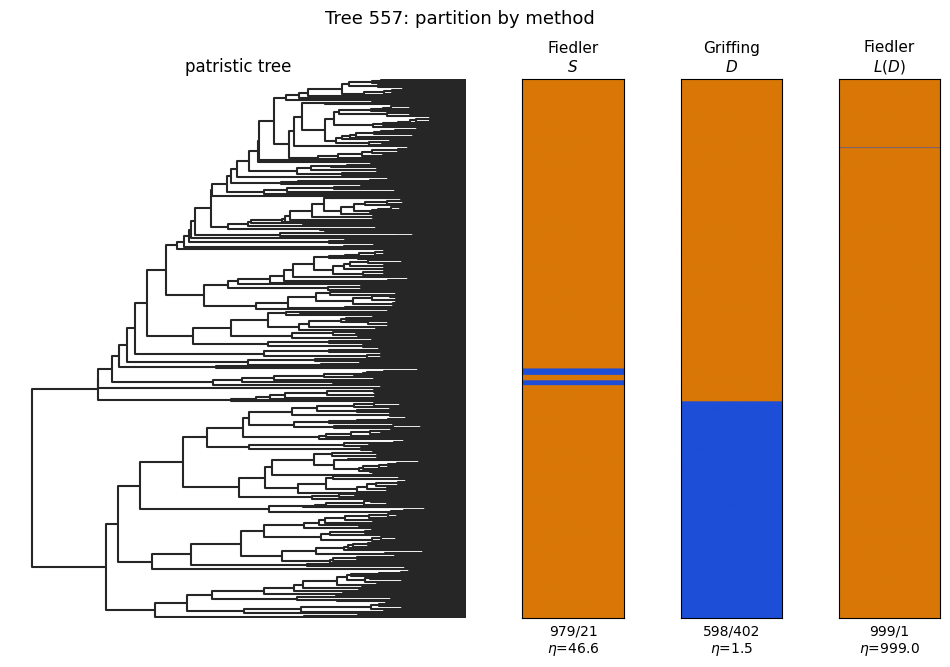

In [11]:
def sign_orient(v):
    s = (np.asarray(v) >= 0).astype(int)
    if s.sum() < len(s) - s.sum():   # make the majority side = 1 (orange) for consistent coloring
        s = 1 - s
    return s

# pick one tree valid in BOTH methods, nearest the griffing-median eta
_fset = set(fiedler_valid_ids)
both  = [t for t in griff_valid_ids if t in _fset]
_gmap = {t: e for t, e in zip(griff_valid_ids, griff_etas)}
_med  = np.median([_gmap[t] for t in both])
tid   = min(both, key=lambda t: abs(_gmap[t] - _med))
print(f'demo tree {tid}  (valid in both; griffing eta={_gmap[tid]:.2f});  {len(both)} trees valid in both')

S, labels, tree = load_S(tid)
D, names = fasta_to_distance(str(FASTA_DIR / f'{tid}.fasta'))
vS  = compute_fiedler_from_laplacian(compute_laplacian(S))     # labels order
vGD = griffing_leading_eigvec(D)                               # names order
vFD = compute_fiedler_from_laplacian(compute_laplacian(D))     # names order

s_to_tree = tree_leaf_index(tree, labels)
nidx = {n: i for i, n in enumerate(names)}
d_to_tree = np.array([nidx[str(l.taxon.label)] for l in tree.leaf_node_iter()])
strips = [('Fiedler\n$S$',    sign_orient(vS[s_to_tree])),
          ('Griffing\n$D$',   sign_orient(vGD[d_to_tree])),
          ('Fiedler\n$L(D)$', sign_orient(vFD[d_to_tree]))]

Dpat = patristic_distance_matrix(tree)
Z = hierarchy.linkage(squareform(Dpat, checks=False), method='average')

fig = plt.figure(figsize=(12, 7))
gs = fig.add_gridspec(1, 4, width_ratios=[4.5, 1, 1, 1], wspace=0.30)
ax_tree = fig.add_subplot(gs[0, 0])
dendro = hierarchy.dendrogram(Z, ax=ax_tree, orientation='left', no_labels=True,
                              color_threshold=0, above_threshold_color='#262626')
leaf_order = dendro['leaves']
ax_tree.set_title('patristic tree', fontsize=12)
ax_tree.set_xticks([]); ax_tree.set_yticks([])
for sp in ax_tree.spines.values(): sp.set_visible(False)

cmap = ListedColormap([COLOR_NEG, COLOR_POS])
for j, (name, sgn) in enumerate(strips, start=1):
    ax = fig.add_subplot(gs[0, j])
    ax.imshow(sgn[leaf_order][:, None], aspect='auto', cmap=cmap, vmin=0, vmax=1, origin='lower')
    n1 = int(sgn.sum()); n2 = len(sgn) - n1
    eta = max(n1, n2) / max(min(n1, n2), 1)
    ax.set_title(name, fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlabel(f'{max(n1,n2)}/{min(n1,n2)}\n$\\eta$={eta:.1f}', fontsize=10)
fig.suptitle(f"Tree {tid.replace('random_tree_','')}: partition by method", fontsize=13)
plt.show()


### What each operator sees — raw inputs vs operators

Same demo tree, rows/cols sorted by the Griffing axis. **Row 1 — raw inputs $S$, $D$.**
**Row 2 — operators $L=\mathrm{Deg}(S)-S$ (Fiedler), $B=HDH$ (Griffing), and
$L_{\rm sym}=I-D^{-1/2}SD^{-1/2}$ (normalised Fiedler).**
Each panel uses its **own** color scale (no shared range), so each operator's structure is visible on its
own terms. Operator panels use a diverging yellow-centered map so $0$ is visible — $L$ is structureless
(degenerate cut) while $B$ and $L_{\rm sym}$ show the $\pm$ block structure of a stable bimodal split.

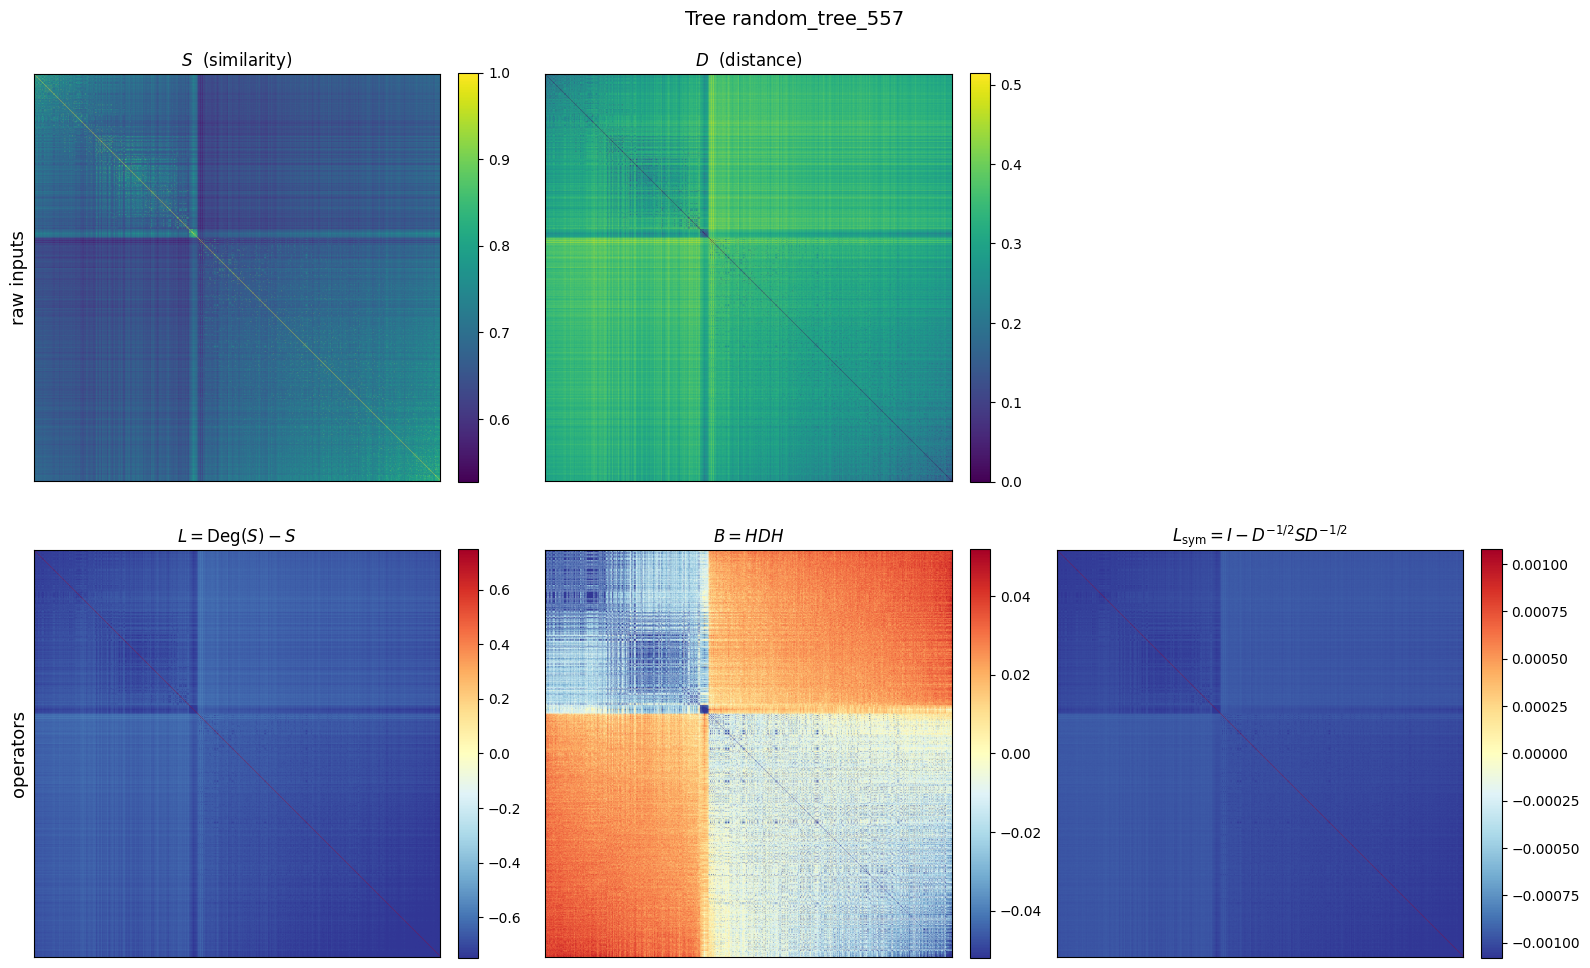

In [12]:
S_m, labels_m, _t_m = load_S(tid)              # tid = the demo tree from the anatomy cell
D_m, names_m = fasta_to_distance(str(FASTA_DIR / f'{tid}.fasta'))
L_m = compute_laplacian(S_m)
B_m = griffing_centered(D_m)
# symmetric normalised Laplacian  L_sym = I - D^{-1/2} S D^{-1/2}   (D = degree matrix of S)
_deg = np.asarray(S_m.sum(axis=1)).ravel()
_dis = 1.0 / np.sqrt(np.maximum(_deg, 1e-12))
Lsym_m = np.eye(len(_deg)) - (S_m * _dis[:, None]) * _dis[None, :]
Lsym_m = 0.5 * (Lsym_m + Lsym_m.T)

order = np.argsort(griffing_leading_eigvec(D_m))   # sort taxa along the Griffing axis
_ro = lambda M: M[order][:, order]
Sr, Dr, Lr, Br, LSr = _ro(S_m), _ro(D_m), _ro(L_m), _ro(B_m), _ro(Lsym_m)

# Each panel keeps its OWN scale (no shared range). Raw inputs: sequential viridis.
# Operators: diverging RdYlBu_r centered at 0, per-matrix range from its own off-diagonal spread.
DIV = 'RdYlBu_r'
def _sym_range(M):
    off = M[~np.eye(M.shape[0], dtype=bool)]
    return float(np.percentile(np.abs(off), 95)) or 1.0

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, Mx, ttl in [(axes[0, 0], Sr, r'$S$  (similarity)'),
                    (axes[0, 1], Dr, r'$D$  (distance)')]:
    im = ax.imshow(Mx, cmap='viridis')
    ax.set_title(ttl, fontsize=12); fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
axes[0, 2].axis('off')

for ax, Mx, ttl in [(axes[1, 0], Lr,  r'$L=\mathrm{Deg}(S)-S$'),
                    (axes[1, 1], Br,  r'$B=HDH$'),
                    (axes[1, 2], LSr, r'$L_{\rm sym}=I-D^{-1/2}SD^{-1/2}$')]:
    v = _sym_range(Mx)
    im = ax.imshow(Mx, cmap=DIV, vmin=-v, vmax=v)
    ax.set_title(ttl, fontsize=12); fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])
axes[0, 0].set_ylabel('raw inputs', fontsize=13)
axes[1, 0].set_ylabel('operators', fontsize=13)
fig.suptitle(f"Tree {tid}", fontsize=14)
fig.tight_layout(); plt.show()


### Recovery curve — similarity vs distance vs normalised

Median NMI vs $p$ over the trees valid in **both** Fiedler-$S$ and Griffing-$D$ (up to 100), with
**all three** operators — $L=\mathrm{Deg}(S)-S$ (similarity), $B=HDH$ (distance), and
$L_{\rm sym}=I-D^{-1/2}SD^{-1/2}$ (normalised) — each recovering its own full-matrix reference.

loaded recovery sweeps from cache


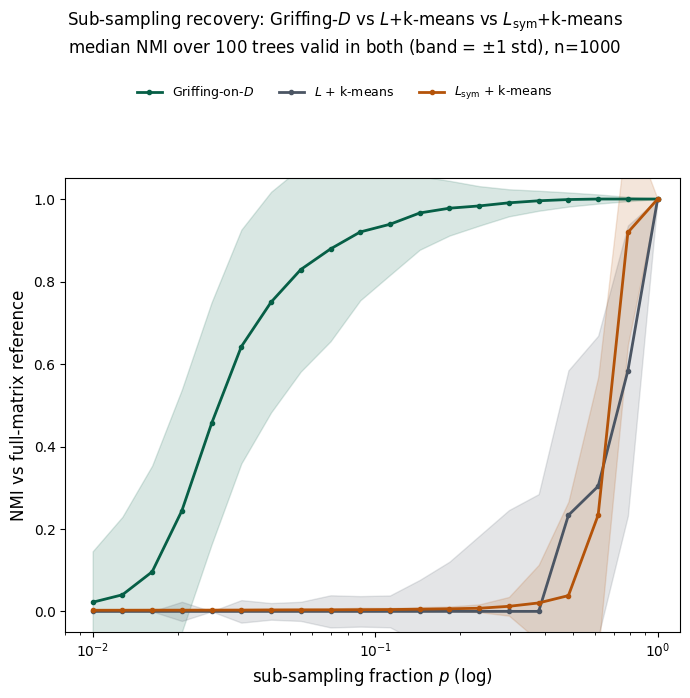

In [16]:
N_COMPARE, REPS = 100, 10
CMP_KM = CACHE_DIR / 'compare_sweep_kmeans_100.npz'   # Griffing-D vs L+kmeans vs L_sym+kmeans
_pvc = np.round(P_VALUES, 6)
cohort = sorted([t for t in griff_valid_ids if t in set(fiedler_valid_ids)])[:N_COMPARE]

def _cache_ok(path, key):
    if not path.exists():
        return None
    z = np.load(path, allow_pickle=True)
    if list(np.round(z['p_values'], 6)) == list(_pvc) and list(z['tree_ids']) == cohort:
        return z[key]
    return None

nmi_G    = _cache_ok(CMP_KM, 'nmi_G')
nmi_L    = _cache_ok(CMP_KM, 'nmi_L')
nmi_Lsym = _cache_ok(CMP_KM, 'nmi_Lsym')
need = nmi_G is None or nmi_L is None or nmi_Lsym is None
if not need:
    print('loaded recovery sweeps from cache')
else:
    print(f'computing recovery sweep: {len(cohort)} trees x {len(P_VALUES)} p x {REPS} reps '
          f'(Griffing-D, L+kmeans, L_sym+kmeans)...')
    _G, _L, _LS = [], [], []
    for ti, tid in enumerate(cohort):
        S, labels, tree = load_S(tid)
        # 1) Griffing on the distance matrix D
        D, names = fasta_to_distance(str(FASTA_DIR / f'{tid}.fasta'))
        raw = bpart_sweep_raw(D, P_VALUES, reps=REPS, seed_base=1000 * ti)
        _G.append(np.array([float(np.mean(pp['nmi'])) for pp in raw['per_p']]))
        # 2) regular (unnormalized) Laplacian + k-means
        fr_L = compute_fiedler_from_laplacian(compute_laplacian(S))
        out_L = bootstrap_p_sweep_simple(S, fr_L, P_VALUES, bootstrap_reps=REPS, seed=1000 * ti,
                                         num_gaps=NUM_GAPS, min_split=MIN_SPLIT,
                                         partition_method='kmeans', laplacian='unnormalized')
        _L.append(np.asarray(out_L['partition_nmi_M'], float))
        # 3) normalized Laplacian L_sym + k-means
        fr_LS = compute_fiedler_from_laplacian(compute_normalized_laplacian(S))
        out_LS = bootstrap_p_sweep_simple(S, fr_LS, P_VALUES, bootstrap_reps=REPS, seed=1000 * ti,
                                          num_gaps=NUM_GAPS, min_split=MIN_SPLIT,
                                          partition_method='kmeans', laplacian='normalized')
        _LS.append(np.asarray(out_LS['partition_nmi_M'], float))
        if (ti + 1) % 5 == 0:
            print(f'  swept {ti+1}/{len(cohort)}')
    nmi_G = np.vstack(_G); nmi_L = np.vstack(_L); nmi_Lsym = np.vstack(_LS)
    np.savez(CMP_KM, p_values=_pvc, tree_ids=np.array(cohort, dtype=object),
             nmi_G=nmi_G, nmi_L=nmi_L, nmi_Lsym=nmi_Lsym)
    print('saved recovery cache:', CMP_KM)

P = np.asarray(_pvc, float)
nt = nmi_G.shape[0]
fig, ax = plt.subplots(figsize=(7, 7))
for data, name, col in [(nmi_G,    'Griffing-on-$D$',           '#065f46'),
                        (nmi_L,    '$L$ + k-means',             '#4b5563'),
                        (nmi_Lsym, '$L_{\\rm sym}$ + k-means',  '#b45309')]:
    med = np.nanmedian(data, 0); sd = np.nanstd(data, 0)
    ax.plot(P, med, color=col, lw=2, marker='o', ms=3, label=name)
    ax.fill_between(P, med - sd, med + sd, color=col, alpha=0.15)
ax.set_xscale('log')
ax.set_xlabel('sub-sampling fraction $p$ (log)', fontsize=12)
ax.set_ylabel('NMI vs full-matrix reference', fontsize=12)
ax.set_xlim(P.min() * 0.8, 1.2); ax.set_ylim(-0.05, 1.05)
_h, _l = ax.get_legend_handles_labels()
fig.suptitle('Sub-sampling recovery: Griffing-$D$ vs $L$+k-means vs $L_{\\rm sym}$+k-means\n'
             f'median NMI over {nt} trees valid in both (band = $\\pm$1 std), n=1000',
             fontsize=12, y=0.99)
fig.legend(_h, _l, loc='upper center', bbox_to_anchor=(0.5, 0.90),
           ncol=len(_l), fontsize=9, frameon=False)
fig.tight_layout(rect=(0, 0, 1, 0.86)); plt.show()


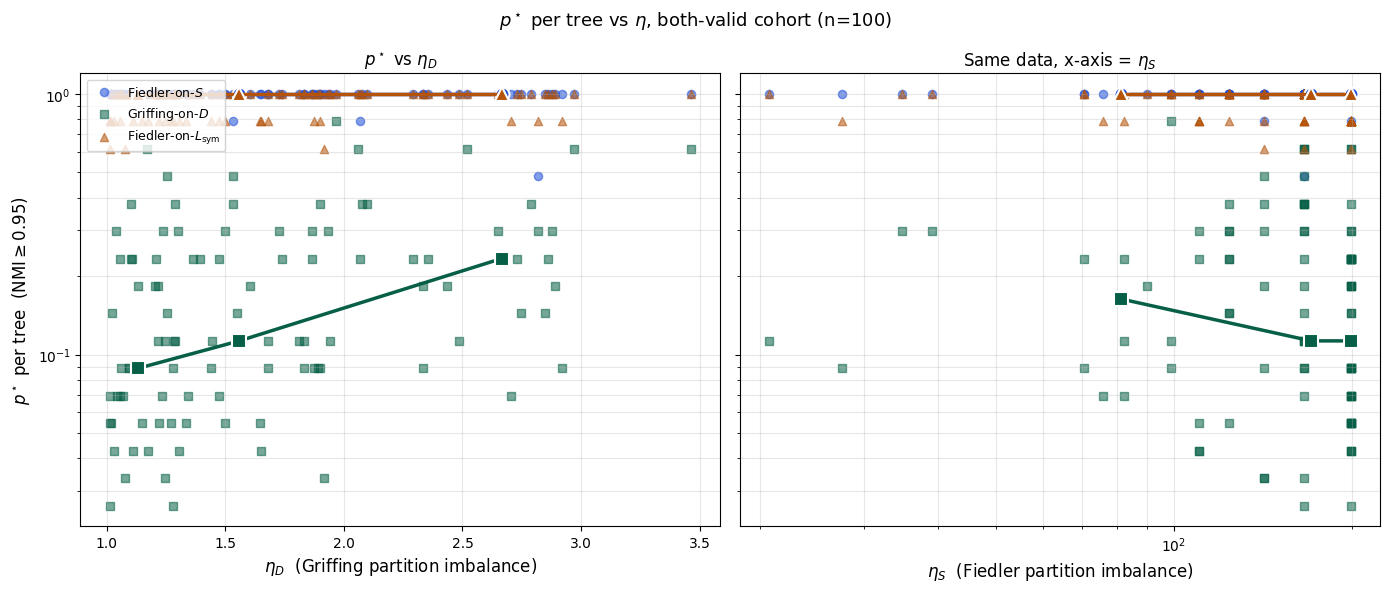

In [ ]:
# p* vs eta (per-tree) on real data — all three methods.
# p* = smallest p with NMI >= 0.95 (from the recovery sweep), plotted against the tree's eta.
# x-axis A = eta_D (Griffing-side, interpretable 1-7 range); B = eta_S (Fiedler-side).
eta_D_per_cohort = np.array([eta_D_map[t] for t in cohort])
eta_S_per_cohort = np.array([eta_S_map[t] for t in cohort])

P_arr    = np.asarray(P_VALUES, float)
pstar_L    = p_star_per_tree(nmi_L,    P_arr)
pstar_G  = p_star_per_tree(nmi_G,  P_arr)
pstar_Lsym = p_star_per_tree(nmi_Lsym, P_arr)

METHODS = [('Griffing-on-$D$',          pstar_G,    '#065f46', 's'),
           ('$L$ + k-means',            pstar_L,    '#4b5563', 'o'),
           ('$L_{\\rm sym}$ + k-means', pstar_Lsym, '#b45309', '^')]

def _panel(ax, x):
    for name, ps, col, mk in METHODS:
        m = np.isfinite(ps) & (ps > 0)
        ax.scatter(x[m], ps[m], color=col, marker=mk, alpha=0.55, s=35, label=name)
    edges = np.quantile(x, [0, 1/3, 2/3, 1.0]); centers = 0.5 * (edges[:-1] + edges[1:])
    for name, ps, col, mk in METHODS:
        m = np.isfinite(ps) & (ps > 0)
        meds = [np.median(ps[m & (x >= lo) & (x <= hi)]) if (m & (x >= lo) & (x <= hi)).any() else np.nan
                for lo, hi in zip(edges[:-1], edges[1:])]
        ax.plot(centers, meds, color=col, lw=2.5, marker=mk, ms=10, mec='white', mew=1.5)
    ax.set_yscale('log'); ax.grid(True, alpha=0.3, which='both')

fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
_panel(a1, eta_D_per_cohort)
a1.set_xlabel(r'$\eta_D$  (Griffing partition imbalance)', fontsize=12)
a1.set_ylabel(r'$p^\star$ per tree  (NMI$\geq 0.95$)', fontsize=12)
a1.set_title(r'$p^\star$ vs $\eta_D$'); a1.legend(fontsize=9, loc='upper left')
_panel(a2, eta_S_per_cohort); a2.set_xscale('log')
a2.set_xlabel(r'$\eta_S$  (Fiedler partition imbalance)', fontsize=12)
a2.set_title(r'Same data, x-axis = $\eta_S$')
fig.suptitle(f'$p^\\star$ per tree vs $\\eta$, both-valid cohort (n={len(cohort)})', fontsize=13)
fig.tight_layout(); plt.show()


loaded rT_cohort.npz


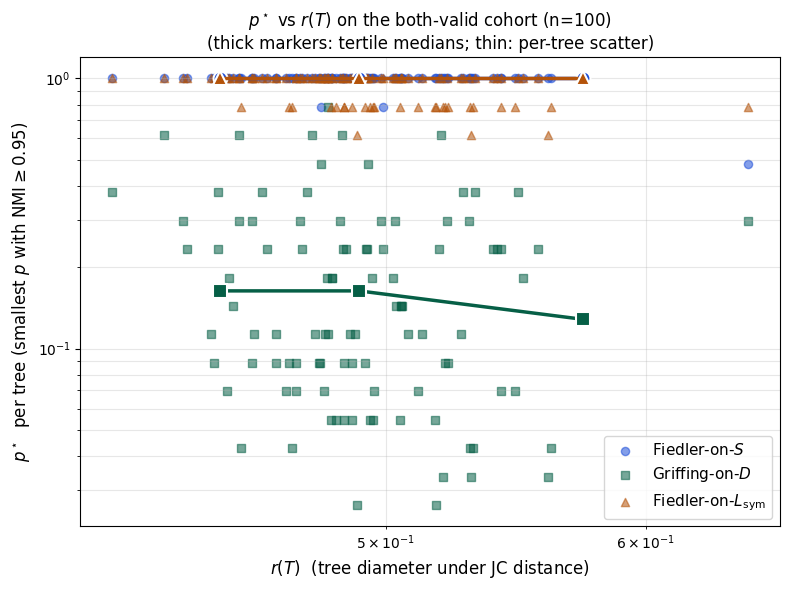

r(T) range: 0.413 – 0.645    median = 0.488
Fiedler-on-$S$: p* finite on 100/100 trees, median=1.000
Griffing-on-$D$: p* finite on 100/100 trees, median=0.144
Fiedler-on-$L_{\rm sym}$: p* finite on 100/100 trees, median=1.000


In [ ]:
# p* vs r(T) on real data — all three methods. m=1000 fixed, so r(T) = tree diameter (per-tree rate).
P_arr    = np.asarray(_pvc, float)
pstar_L    = p_star_per_tree(nmi_L,    P_arr)
pstar_G  = p_star_per_tree(nmi_G,  P_arr)
pstar_Lsym = p_star_per_tree(nmi_Lsym, P_arr)
METHODS = [('Griffing-on-$D$',          pstar_G,    '#065f46', 's'),
           ('$L$ + k-means',            pstar_L,    '#4b5563', 'o'),
           ('$L_{\\rm sym}$ + k-means', pstar_Lsym, '#b45309', '^')]

RT_CACHE = CACHE_DIR / 'rT_cohort.npz'
_rt_loaded = False
if RT_CACHE.exists():
    zr = np.load(RT_CACHE, allow_pickle=True)
    if list(zr['cohort']) == list(cohort):
        rT_per_tree = np.asarray(zr['rT'], float); _rt_loaded = True
        print(f'loaded {RT_CACHE}')
if not _rt_loaded:
    print(f'computing r(T) on {len(cohort)} cohort trees...')
    rT_per_tree = []
    for ti, tid in enumerate(cohort):
        Dt, _ = fasta_to_distance(str(FASTA_DIR / f'{tid}.fasta'))
        rT_per_tree.append(float(Dt.max()))
    rT_per_tree = np.asarray(rT_per_tree, float)
    np.savez(RT_CACHE, cohort=np.array(cohort, dtype=object), rT=rT_per_tree)
    print(f'saved {RT_CACHE}')

fig, ax = plt.subplots(figsize=(8, 6))
for name, ps, col, mk in METHODS:
    m = np.isfinite(ps) & (ps > 0)
    ax.scatter(rT_per_tree[m], ps[m], color=col, marker=mk, alpha=0.55, s=35, label=name)
if any((np.isfinite(ps) & (ps > 0)).sum() >= 6 for _, ps, _, _ in METHODS):
    edges = np.quantile(rT_per_tree, [0, 1/3, 2/3, 1.0]); centers = 0.5 * (edges[:-1] + edges[1:])
    for name, ps, col, mk in METHODS:
        m = np.isfinite(ps) & (ps > 0)
        meds = [np.median(ps[m & (rT_per_tree >= lo) & (rT_per_tree <= hi)])
                if (m & (rT_per_tree >= lo) & (rT_per_tree <= hi)).any() else np.nan
                for lo, hi in zip(edges[:-1], edges[1:])]
        ax.plot(centers, meds, color=col, lw=2.5, marker=mk, ms=10, mec='white', mew=1.5)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'$r(T)$  (tree diameter under JC distance)', fontsize=12)
ax.set_ylabel(r'$p^\star$  per tree (smallest $p$ with NMI$\geq 0.95$)', fontsize=12)
ax.set_title(f'$p^\\star$ vs $r(T)$ on the both-valid cohort (n={len(cohort)})\n'
             f'(thick markers: tertile medians; thin: per-tree scatter)', fontsize=12)
ax.legend(fontsize=11, loc='best'); ax.grid(True, alpha=0.3, which='both')
fig.tight_layout(); plt.show()

print(f'r(T) range: {rT_per_tree.min():.3f} – {rT_per_tree.max():.3f}    median = {np.median(rT_per_tree):.3f}')
for name, ps, _, _ in METHODS:
    m = np.isfinite(ps) & (ps > 0)
    print(f'{name}: p* finite on {int(m.sum())}/{len(cohort)} trees, median={np.nanmedian(ps[m]):.3f}' if m.any()
          else f'{name}: p* finite on 0/{len(cohort)} trees')
